## Langchain Version V1

In [23]:
import os
from dotenv import load_dotenv
load_dotenv()

import langchain
print(langchain.__version__)

os.environ["GPT-4-MINI_API_KEY"] = os.getenv("GPT-4-MINI_API_KEY")

1.2.13


In [8]:
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain_openai import ChatOpenAI

llm = init_chat_model(
    model="gpt-4.1-mini",
    model_provider="openai",
    api_key=os.getenv("GPT-4-MINI_API_KEY"),
    base_url="https://models.inference.ai.azure.com"
)

def get_current_weather(city: str) -> str:
    """Get the weather for a city."""
    return f"The current weather in {city} is sunny"

agent = create_agent(
    model=llm,
    tools=[get_current_weather],
    system_prompt="You are a helpful assistant that provides information about the weather. Answer questions about the current weather conditions in various cities around the world."
)

**NOTE:** For get_current_weather function the documentation is needed """Get the weather for a city.""" for creating the agent

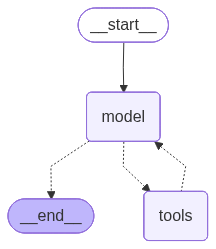

In [9]:
agent

In [11]:
response = agent.invoke({"messages": [{"role": "user", "content": "What is the current weather in New York?"}]})

In [21]:
response['messages'][-1].content

'The current weather in New York is sunny. If you need more detailed information or weather conditions for other cities, feel free to ask!'

In [22]:
agent.invoke({"messages":"What is the weather in New Yourk"})

{'messages': [HumanMessage(content='What is the weather in New Yourk', additional_kwargs={}, response_metadata={}, id='0d6a11c7-8b7d-4d3f-94f5-c38ff9632b96'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 79, 'total_tokens': 96, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_b6f445fc1c', 'id': 'chatcmpl-DLSS8vLaLqEzcq0KeL8bPhJhs5iKg', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d0b08-f507-7b02-8138-35eafff4e845-0', tool_calls=[{'name': 'get_current_weather', 'args': {'city': 'New York'}, 'id': 'call_kg2twBrV2l6kH14omBx3VzMC', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 79, 'output_tokens': 17

### Streaming

Most models can stream their output content while it is being generated. By displaying output progressively, streaming significantly improves user experience, particularly for longer responses. Calling stream() returns an iterator that yields output chunks as they are produced. You can use a loop to process each chunk in real-time.

In [24]:
llm.invoke("Why do parrots have colourful feathers?")

AIMessage(content='Parrots have colorful feathers primarily for a combination of **communication, camouflage, and mating purposes**. Here’s a detailed explanation:\n\n1. **Communication and Social Interaction:**  \n   Brightly colored feathers help parrots recognize one another and convey important social signals. Color patterns can indicate species, sex, age, or individual identity, which is crucial in their social groups for establishing bonds, dominance hierarchies, or signaling readiness to mate.\n\n2. **Mating and Attraction:**  \n   Vivid colors are often a way to attract mates. In many bird species, including parrots, brighter and more vibrant plumage can be a sign of good health and strong genetics, making those individuals more attractive to potential partners.\n\n3. **Camouflage in Their Natural Habitat:**  \n   Although parrots are brightly colored, these colors can actually blend well with the lush, vibrant environments they live in, such as tropical rainforests. The combin

In [28]:
for chunk in llm.stream("Why do parrots have colourful feathers?"):
    print(chunk.text, end= "", flush=True)

Parrots have colourful feathers primarily for reasons related to communication, camouflage, and mate attraction:

1. **Communication and Social Signaling:** Brightly colored feathers help parrots recognize each other, establish social bonds, and convey information about their identity, species, age, and even mood.

2. **Mate Attraction:** Vivid colors often indicate good health and genetic fitness. During mating seasons, parrots use their bright plumage to attract potential mates by displaying their vibrant feathers, signaling that they are strong and healthy partners.

3. **Camouflage:** Although it might seem counterintuitive, the bright colors can help parrots blend into their natural environment—such as the colorful fruits, flowers, and foliage found in tropical forests—making them less conspicuous to predators.

Additionally, the coloration in parrots comes from pigments like psittacofulvins (unique to parrots) and structural coloration caused by microscopic feather structures tha

### Batch

Batching is collection of indepedent requests to a model can significantly improve performance and reduce costs, as the processing can be done in paralle.

In [29]:
responses = llm.batch([
    "What is the capital of France?",
    "What is the largest mammal?",
    "What is the meaning of life?"
])
for response in responses:
    print(response.text)

The capital of France is Paris.
The largest mammal is the blue whale (*Balaenoptera musculus*). It is also the largest animal known to have ever existed. Adult blue whales can reach lengths of up to about 100 feet (30 meters) and can weigh as much as 200 tons or more.
The meaning of life is a profound and personal question that has been explored by philosophers, religious traditions, scientists, and thinkers throughout history. Different perspectives offer varied answers:

- **Philosophical**: Some suggest life's meaning is self-created, emphasizing purpose through personal growth, relationships, and contributions to others.
- **Religious**: Many faiths propose that life’s meaning is connected to fulfilling a divine purpose or spiritual journey.
- **Scientific**: From a biological standpoint, life’s purpose can be seen as survival and reproduction.
- **Existential**: Existentialists often argue that life has no inherent meaning except what individuals give it.

Ultimately, the meaning 

In [30]:
responses = llm.batch(
    ["What is the capital of France?",
    "What is the largest mammal?",
    "What is the meaning of life?"],
    config={
        'max_concurrency':5,    # Limit the number of concurrent requests
    }
)
for response in responses:
    print(response.text)

The capital of France is Paris.
The largest mammal is the blue whale (*Balaenoptera musculus*). It is not only the largest mammal but also the largest animal known to have ever existed. Blue whales can reach lengths of up to about 100 feet (30 meters) and weigh as much as 200 tons or more.
The question "What is the meaning of life?" has been explored by philosophers, scientists, theologians, and thinkers throughout history, and different perspectives offer various answers. 

Some common viewpoints include:

- **Philosophical:** Many propose that life’s meaning is something each person creates through their choices, relationships, and experiences.
- **Religious/Spiritual:** Various traditions suggest that life’s meaning is connected to a higher power, spiritual growth, or fulfilling a divine purpose.
- **Scientific/Naturalistic:** From this perspective, life may not have an inherent meaning beyond survival and reproduction, but humans can find purpose through curiosity, creativity, and 